In [15]:
import numpy as np
import pandas as pd

In [ ]:
CANDIDATES_PATH = '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy'
FULL_META_PATH  = '/home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl'

# Load candidates and full per-spectrum metadata
candidates = np.load(CANDIDATES_PATH, allow_pickle=True)
cand_set   = set(candidates.tolist())

full_meta  = pd.read_pickle(FULL_META_PATH)
name_col   = 'Reduced' if 'Reduced' in full_meta.columns else 'Object'

# Filter to qualifying groups only
filtered = full_meta[full_meta[name_col].isin(cand_set)][['Reduced', 'SPEC_RES']].copy()

# For each group: count unique SPEC_RES values
group_res = filtered.groupby(name_col)['SPEC_RES'].apply(lambda x: len(x.dropna().unique()))

n_uniform = (group_res == 1).sum()
n_mixed   = (group_res > 1).sum()
total = n_uniform + n_mixed

pct_uniform = 100 * n_uniform / total
pct_mixed   = 100 * n_mixed / total

print(f'Uniform resolution:   {n_uniform} ({pct_uniform:.1f}%)')
print(f'Mixed resolution:     {n_mixed} ({pct_mixed:.1f}%)')

Uniform resolution:   333
Mixed resolution:     164


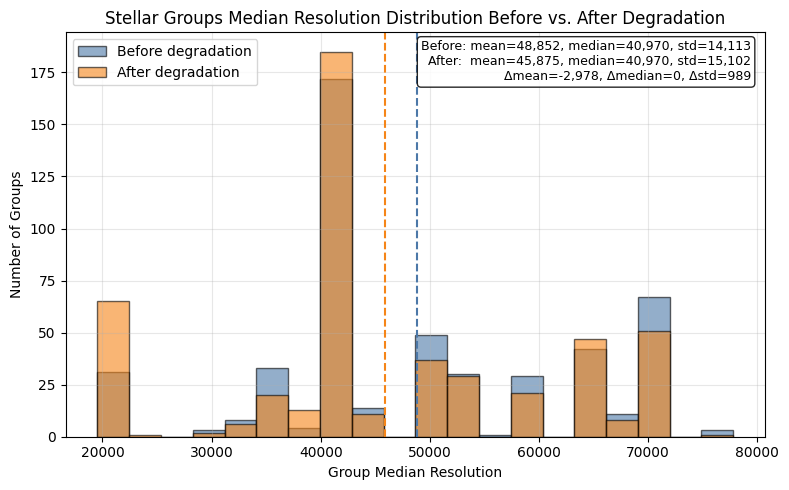

Saved: /home/msp25gd/ResearchProjectMSc/Images/group_resolution_distribution.png
Before degradation summary:
{'mean': '48,852', 'median': '40,970', 'std': '14,113'}
After degradation summary:
{'mean': '45,875', 'median': '40,970', 'std': '15,102'}
Differences after degradation:
{'delta_mean': '-2,978', 'delta_median': '0', 'delta_std': '989'}


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure the notebook can run even if earlier cells were not executed yet.
if 'CANDIDATES_PATH' not in globals():
    CANDIDATES_PATH = '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy'
if 'FULL_META_PATH' not in globals():
    FULL_META_PATH = '/home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl'

processed_root = Path('/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates')
out_dir = Path('/home/msp25gd/ResearchProjectMSc/Images')
out_dir.mkdir(exist_ok=True)

candidates = np.load(CANDIDATES_PATH, allow_pickle=True)
cand_set = set(candidates.tolist())

full_meta = pd.read_pickle(FULL_META_PATH)
name_col = 'Reduced' if 'Reduced' in full_meta.columns else 'Object'


def _group_resolution_values(meta, groups):
    values = {}
    for group in groups:
        group_key = str(group).strip()
        sub = meta[meta[name_col].astype(str).str.strip() == group_key]
        res = pd.to_numeric(sub['SPEC_RES'], errors='coerce').dropna()
        if not res.empty:
            values[group_key] = float(np.median(res))
    return pd.Series(values)


before_series = _group_resolution_values(full_meta, sorted(cand_set))
after_series = {}
for group in sorted(cand_set):
    group_key = str(group).strip()
    meta_path = processed_root / group_key / 'meta' / 'group_df.pkl'
    if not meta_path.exists():
        continue
    try:
        meta = pd.read_pickle(meta_path)
    except Exception:
        continue
    if 'SPEC_RES' not in meta.columns:
        continue
    res = pd.to_numeric(meta['SPEC_RES'], errors='coerce').dropna()
    if not res.empty:
        after_series[group_key] = float(np.median(res))

after_series = pd.Series(after_series)

common_groups = before_series.index.intersection(after_series.index)
before_vals = before_series.loc[common_groups].astype(float)
after_vals = after_series.loc[common_groups].astype(float)


def _summarize(values):
    return {
        'mean': float(values.mean()),
        'median': float(values.median()),
        'std': float(values.std(ddof=0)),
    }


def _fmt(v):
    return f'{v:,.0f}'


before_stats = _summarize(before_vals)
after_stats = _summarize(after_vals)

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.histogram_bin_edges(np.concatenate([before_vals, after_vals]), bins=20)
ax.hist(before_vals, bins=bins, alpha=0.6, color='#4C78A8', edgecolor='black', label='Before degradation')
ax.hist(after_vals, bins=bins, alpha=0.6, color='#F58518', edgecolor='black', label='After degradation')

for label, stats in [('Before', before_stats), ('After', after_stats)]:
    ax.axvline(stats['mean'], linestyle='--', color='#4C78A8' if label == 'Before' else '#F58518', linewidth=1.5)

ax.set_title('Stellar Groups Median Resolution Distribution Before vs. After Degradation')
ax.set_xlabel('Group Median Resolution')
ax.set_ylabel('Number of Groups')
ax.grid(True, alpha=0.3)
ax.legend()

summary_text = (
    f"Before: mean={_fmt(before_stats['mean'])}, median={_fmt(before_stats['median'])}, std={_fmt(before_stats['std'])}\n"
    f"After:  mean={_fmt(after_stats['mean'])}, median={_fmt(after_stats['median'])}, std={_fmt(after_stats['std'])}\n"
    f"Δmean={_fmt(after_stats['mean'] - before_stats['mean'])}, "
    f"Δmedian={_fmt(after_stats['median'] - before_stats['median'])}, "
    f"Δstd={_fmt(after_stats['std'] - before_stats['std'])}"
)
ax.text(0.98, 0.98, summary_text, transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig.tight_layout()
fig.savefig(out_dir / 'group_resolution_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', out_dir / 'group_resolution_distribution.png')
print('Before degradation summary:')
print({k: _fmt(v) for k, v in before_stats.items()})
print('After degradation summary:')
print({k: _fmt(v) for k, v in after_stats.items()})
print('Differences after degradation:')
print({
    'delta_mean': _fmt(after_stats['mean'] - before_stats['mean']),
    'delta_median': _fmt(after_stats['median'] - before_stats['median']),
    'delta_std': _fmt(after_stats['std'] - before_stats['std']),
})

In [3]:
print(f"Total stars used in the median-resolution comparison: {len(common_groups)}")

Total stars used in the median-resolution comparison: 497


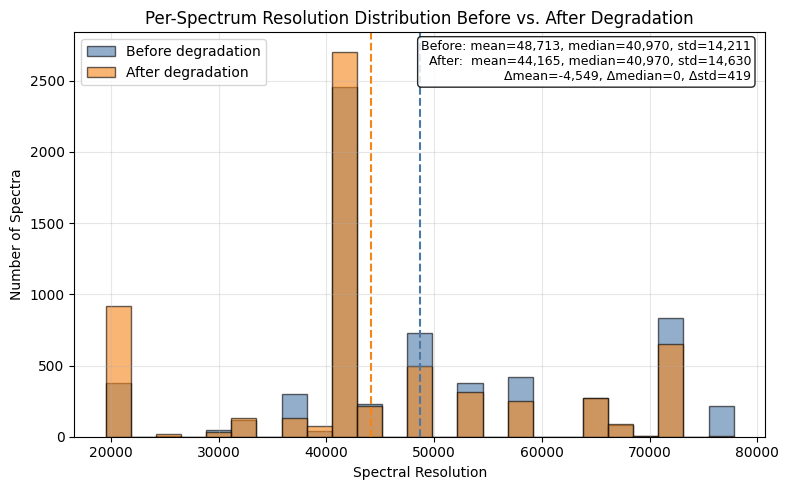

Saved: /home/msp25gd/ResearchProjectMSc/Images/spectrum_resolution_distribution.png
Before degradation summary:
{'mean': '48,713', 'median': '40,970', 'std': '14,211'}
After degradation summary:
{'mean': '44,165', 'median': '40,970', 'std': '14,630'}
Differences after degradation:
{'delta_mean': '-4,549', 'delta_median': '0', 'delta_std': '419'}


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if 'CANDIDATES_PATH' not in globals():
    CANDIDATES_PATH = '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy'
if 'FULL_META_PATH' not in globals():
    FULL_META_PATH = '/home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl'

processed_root = Path('/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates')
out_dir = Path('/home/msp25gd/ResearchProjectMSc/Images')
out_dir.mkdir(exist_ok=True)

candidates = np.load(CANDIDATES_PATH, allow_pickle=True)
cand_set = {str(c).strip() for c in candidates.tolist()}

full_meta = pd.read_pickle(FULL_META_PATH)
name_col = 'Reduced' if 'Reduced' in full_meta.columns else 'Object'


def _collect_spectrum_resolutions(meta, groups):
    values = []
    for group in groups:
        group_key = str(group).strip()
        sub = meta[meta[name_col].astype(str).str.strip() == group_key]
        if sub.empty:
            continue
        vals = pd.to_numeric(sub['SPEC_RES'], errors='coerce').dropna().astype(float)
        if not vals.empty:
            values.extend(vals.tolist())
    return np.array(values, dtype=float)


before_vals = _collect_spectrum_resolutions(full_meta, cand_set)
after_vals = []
for group in cand_set:
    group_key = str(group).strip()
    meta_path = processed_root / group_key / 'meta' / 'group_df.pkl'
    if not meta_path.exists():
        continue
    try:
        meta = pd.read_pickle(meta_path)
    except Exception:
        continue
    if 'SPEC_RES' not in meta.columns:
        continue
    vals = pd.to_numeric(meta['SPEC_RES'], errors='coerce').dropna().astype(float)
    if not vals.empty:
        after_vals.extend(vals.tolist())

after_vals = np.array(after_vals, dtype=float)

before_vals = before_vals[~np.isnan(before_vals)]
after_vals = after_vals[~np.isnan(after_vals)]


def _summarize(values):
    return {
        'mean': float(np.mean(values)),
        'median': float(np.median(values)),
        'std': float(np.std(values, ddof=0)),
    }


def _fmt(v):
    return f'{v:,.0f}'


before_stats = _summarize(before_vals)
after_stats = _summarize(after_vals)

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.histogram_bin_edges(np.concatenate([before_vals, after_vals]), bins=25)
ax.hist(before_vals, bins=bins, alpha=0.6, color='#4C78A8', edgecolor='black', label='Before degradation')
ax.hist(after_vals, bins=bins, alpha=0.6, color='#F58518', edgecolor='black', label='After degradation')

for label, stats in [('Before', before_stats), ('After', after_stats)]:
    ax.axvline(stats['mean'], linestyle='--', color='#4C78A8' if label == 'Before' else '#F58518', linewidth=1.5)

ax.set_title('Per-Spectrum Resolution Distribution Before vs. After Degradation')
ax.set_xlabel('Spectral Resolution')
ax.set_ylabel('Number of Spectra')
ax.grid(True, alpha=0.3)
ax.legend()

summary_text = (
    f"Before: mean={_fmt(before_stats['mean'])}, median={_fmt(before_stats['median'])}, std={_fmt(before_stats['std'])}\n"
    f"After:  mean={_fmt(after_stats['mean'])}, median={_fmt(after_stats['median'])}, std={_fmt(after_stats['std'])}\n"
    f"Δmean={_fmt(after_stats['mean'] - before_stats['mean'])}, "
    f"Δmedian={_fmt(after_stats['median'] - before_stats['median'])}, "
    f"Δstd={_fmt(after_stats['std'] - before_stats['std'])}"
)
ax.text(0.98, 0.98, summary_text, transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

fig.tight_layout()
fig.savefig(out_dir / 'spectrum_resolution_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', out_dir / 'spectrum_resolution_distribution.png')
print('Before degradation summary:')
print({k: _fmt(v) for k, v in before_stats.items()})
print('After degradation summary:')
print({k: _fmt(v) for k, v in after_stats.items()})
print('Differences after degradation:')
print({
    'delta_mean': _fmt(after_stats['mean'] - before_stats['mean']),
    'delta_median': _fmt(after_stats['median'] - before_stats['median']),
    'delta_std': _fmt(after_stats['std'] - before_stats['std']),
})

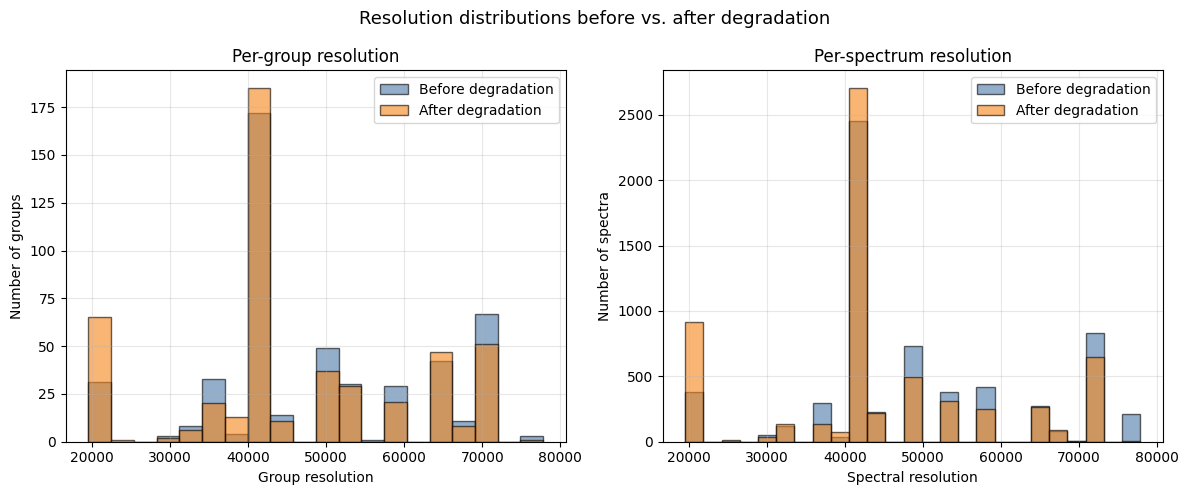

Group-level summary:
{'before': {'mean': '48,852', 'median': '40,970', 'std': '14,113'}, 'after': {'mean': '45,875', 'median': '40,970', 'std': '15,102'}}
Spectrum-level summary:
{'before': {'mean': '48,713', 'median': '40,970', 'std': '14,211'}, 'after': {'mean': '44,165', 'median': '40,970', 'std': '14,630'}}


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if 'CANDIDATES_PATH' not in globals():
    CANDIDATES_PATH = '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch_V2/candidates_-3.5sig_1.5cut_2width_V2.npy'
if 'FULL_META_PATH' not in globals():
    FULL_META_PATH = '/home/msp25gd/Downloads/res/meta/full_metadata_V2.pkl'

processed_root = Path('/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates')

candidates = np.load(CANDIDATES_PATH, allow_pickle=True)
cand_set = {str(c).strip() for c in candidates.tolist()}

full_meta = pd.read_pickle(FULL_META_PATH)
name_col = 'Reduced' if 'Reduced' in full_meta.columns else 'Object'


def _group_resolution_values(meta, groups, stat='median'):
    values = {}
    for group in groups:
        group_key = str(group).strip()
        sub = meta[meta[name_col].astype(str).str.strip() == group_key]
        res = pd.to_numeric(sub['SPEC_RES'], errors='coerce').dropna()
        if not res.empty:
            values[group_key] = float(getattr(np, stat)(res))
    return pd.Series(values)


def _collect_spectrum_resolutions(meta, groups):
    values = []
    for group in groups:
        group_key = str(group).strip()
        sub = meta[meta[name_col].astype(str).str.strip() == group_key]
        if sub.empty:
            continue
        vals = pd.to_numeric(sub['SPEC_RES'], errors='coerce').dropna().astype(float)
        if not vals.empty:
            values.extend(vals.tolist())
    return np.array(values, dtype=float)


before_group_series = _group_resolution_values(full_meta, sorted(cand_set), stat='median')
after_group_series = {}
for group in sorted(cand_set):
    group_key = str(group).strip()
    meta_path = processed_root / group_key / 'meta' / 'group_df.pkl'
    if not meta_path.exists():
        continue
    try:
        meta = pd.read_pickle(meta_path)
    except Exception:
        continue
    if 'SPEC_RES' not in meta.columns:
        continue
    res = pd.to_numeric(meta['SPEC_RES'], errors='coerce').dropna()
    if not res.empty:
        after_group_series[group_key] = float(np.median(res))
after_group_series = pd.Series(after_group_series)

common_groups = before_group_series.index.intersection(after_group_series.index)
before_group_vals = before_group_series.loc[common_groups].astype(float)
after_group_vals = after_group_series.loc[common_groups].astype(float)

before_spec_vals = _collect_spectrum_resolutions(full_meta, cand_set)
after_spec_vals = []
for group in cand_set:
    group_key = str(group).strip()
    meta_path = processed_root / group_key / 'meta' / 'group_df.pkl'
    if not meta_path.exists():
        continue
    try:
        meta = pd.read_pickle(meta_path)
    except Exception:
        continue
    if 'SPEC_RES' not in meta.columns:
        continue
    vals = pd.to_numeric(meta['SPEC_RES'], errors='coerce').dropna().astype(float)
    if not vals.empty:
        after_spec_vals.extend(vals.tolist())
after_spec_vals = np.array(after_spec_vals, dtype=float)

before_group_vals = before_group_vals[~np.isnan(before_group_vals)]
after_group_vals = after_group_vals[~np.isnan(after_group_vals)]
before_spec_vals = before_spec_vals[~np.isnan(before_spec_vals)]
after_spec_vals = after_spec_vals[~np.isnan(after_spec_vals)]


def _fmt(v):
    return f'{v:,.0f}'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Left: group-level distributions
bins_g = np.histogram_bin_edges(np.concatenate([before_group_vals, after_group_vals]), bins=20)
axes[0].hist(before_group_vals, bins=bins_g, alpha=0.6, color='#4C78A8', edgecolor='black', label='Before degradation')
axes[0].hist(after_group_vals, bins=bins_g, alpha=0.6, color='#F58518', edgecolor='black', label='After degradation')
axes[0].set_title('Per-group resolution')
axes[0].set_xlabel('Group resolution')
axes[0].set_ylabel('Number of groups')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right: per-spectrum distributions
bins_s = np.histogram_bin_edges(np.concatenate([before_spec_vals, after_spec_vals]), bins=25)
axes[1].hist(before_spec_vals, bins=bins_s, alpha=0.6, color='#4C78A8', edgecolor='black', label='Before degradation')
axes[1].hist(after_spec_vals, bins=bins_s, alpha=0.6, color='#F58518', edgecolor='black', label='After degradation')
axes[1].set_title('Per-spectrum resolution')
axes[1].set_xlabel('Spectral resolution')
axes[1].set_ylabel('Number of spectra')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle('Resolution distributions before vs. after degradation', fontsize=13)
fig.tight_layout()
plt.show()

print('Group-level summary:')
print({'before': {k: _fmt(v) for k, v in {'mean': float(np.mean(before_group_vals)), 'median': float(np.median(before_group_vals)), 'std': float(np.std(before_group_vals, ddof=0))}.items()},
       'after': {k: _fmt(v) for k, v in {'mean': float(np.mean(after_group_vals)), 'median': float(np.median(after_group_vals)), 'std': float(np.std(after_group_vals, ddof=0))}.items()}})
print('Spectrum-level summary:')
print({'before': {k: _fmt(v) for k, v in {'mean': float(np.mean(before_spec_vals)), 'median': float(np.median(before_spec_vals)), 'std': float(np.std(before_spec_vals, ddof=0))}.items()},
       'after': {k: _fmt(v) for k, v in {'mean': float(np.mean(after_spec_vals)), 'median': float(np.median(after_spec_vals)), 'std': float(np.std(after_spec_vals, ddof=0))}.items()}})